In [87]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [88]:

def split_data(data, train_size=0.75, random_state=42, bias_row=True):
    x,y = data[:, :9], data[:, 9:]
    if bias_row:
        x = np.concatenate((np.ones((x.shape[0], 1)), x), axis=1)
    y = y/2 - 1


    return train_test_split(x, y, train_size=train_size, random_state=random_state, stratify=y)

In [162]:
data = np.loadtxt('rp.data').astype(int)
print(data.shape)


(683, 10)


In [90]:

def regularization(phi, lambda1, lambda2):
    return lambda1 * np.sum(np.abs(phi[1:])) + lambda2 * np.sum(phi[1:]**2)

In [91]:
def sig(x, theta):
    return 1 / (1 + np.exp(-x @ theta)).reshape(-1, 1)
def loss(X, y, theta, lambda1, lambda2):
    m = len(X),
    h = sig(X, theta)
    eps = 1e-15
    h = np.clip(h, eps, 1 - eps)
    return np.mean(-y * np.log(h) - (1 - y) * np.log(1 - h)) + regularization(theta, lambda1, lambda2)/m

In [92]:
def accuracy(X, y, theta):
    h = sig(X, theta)
    predictions = (h >= 0.5).astype(int)
    return np.mean(predictions == y)

In [93]:
def gradient(X, y, theta, lambda1, lambda2  ):
    m = X.shape[0]
    h = sig(X, theta)
    grad = np.empty_like(theta)
    grad = (X.T @ (h - y)) / m

    reg = lambda1 * np.sign(theta) + 2 * lambda2 * theta
    reg[0] = 0 

    return grad + reg/m

In [132]:
def gradient_descent(
                    x_train, y_train, x_test, y_test, phi,
                    loss_function, gradient_function,
                    learning_rate, epochs, batch_size, lambda1, lambda2,
                    learning_rate_decay, verbose=True
                    ):
    cross_entropy_history = []
    accuracy_history = []
    for epoch in range(epochs):
        perm = np.random.permutation(x_train.shape[0])
        x_shuffled = x_train[perm]
        y_shuffled = y_train[perm]
        for i in range(0, x_train.shape[0], batch_size):
            gradient = gradient_function(x_shuffled[i:i+batch_size, :], y_shuffled[i:i+batch_size, :], phi,  lambda1, lambda2)
            phi -= gradient * learning_rate
        learning_rate *= learning_rate_decay
        cross_entropy = loss_function(x_test, y_test, phi, lambda1, lambda2)
        cross_entropy_history.append(cross_entropy[0])
        accuracy_score = accuracy(x_test, y_test, phi)
        accuracy_history.append(accuracy_score)
        if verbose:
            print(f"Epoch {epoch + 1}: cross_entropy = {cross_entropy[0]}, Accuracy = {accuracy_score}")
    return cross_entropy_history, accuracy_history


/tmp/ipykernel_541065/1354972214.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


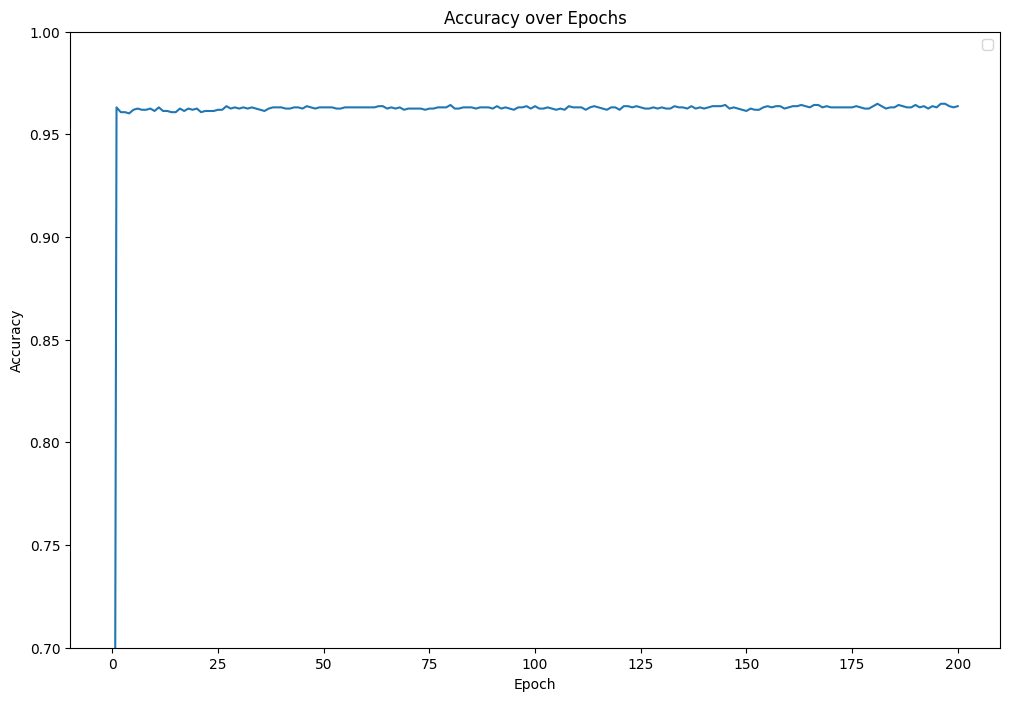

In [ ]:

n_tests = 10
epochs = 200
batch_size = 16
learning_rate = 0.01
learning_rate_decay = 1
lambda1 = 0
lambda2 = 0.1
phi = np.zeros((10, 1))
fig, axes = plt.subplots(figsize=(12, 8))

avg_acc_history = np.zeros(epochs + 1)
for i in range(n_tests):
    
    X_train,  X_test, y_train, y_test = split_data(data, random_state=i)
    avg_acc_history[0] = accuracy(X_test, y_test, phi)
    cross_entropy_history, accuracy_history = gradient_descent(
                    X_train, y_train, X_test, y_test, phi,
                    loss, gradient,
                    learning_rate, epochs, batch_size, lambda1, lambda2
                    , learning_rate_decay, verbose=False)
    avg_acc_history[1:] += np.array(accuracy_history)
avg_acc_history /= n_tests

axes.plot(range(0, epochs+1), avg_acc_history)
axes.set_title('Accuracy over Epochs')
axes.set_xlabel('Epoch')
axes.set_ylim(0.7, 1)
axes.set_ylabel('Accuracy')
axes.legend()
plt.show()

In [ ]:

def nb_params(X, y):
    n_features = X.shape[1]
    n_classes = 2
    num_values = 10
    phi = {}
    priors = {}
    for c in range(n_classes):
        X_c = X[y.flatten() == c]
        N_c = X_c.shape[0]
        
        priors[c] = (N_c + 1) / (X.shape[0] + n_classes)
        phi_c = np.zeros((n_features, num_values))
        for j in range(n_features):
            for d in range(1, num_values  + 1):
                phi_c[j, d - 1] = (np.sum(X_c[:, j] == d) + 1) / (N_c + num_values)
        phi[c] = phi_c
    return phi, priors


In [ ]:
def predict_one(x, phi, priors):
    best_class = None
    best_log_prob = -np.inf

    for c in phi:
        log_prob = np.log(priors[c])

        for j in range(len(x)):
            d = int(x[j]) - 1   
            log_prob += np.log(phi[c][j, d])

        if log_prob > best_log_prob:
            best_log_prob = log_prob
            best_class = c

    return best_class

In [ ]:
def nb_accuracy(X, y, phi, priors):
    y_pred = np.array([predict_one(X[i], phi, priors) for i in range(X.shape[0])])
    return np.mean(y_pred == y.flatten())


In [159]:
phi, priors = nb_params(X_train, y_train)
nb_acc = nb_accuracy(X_test, y_test, phi, priors)

print(f"Naive Bayes Accuracy: {nb_acc}")

Naive Bayes Accuracy: 0.9824561403508771


In [161]:
num_tests = 20
batch_size = 16
learning_rate = 0.01
learning_rate_decay = 1
lambda1 = 0
lambda2 = 0.1
epochs = 1000
fracs = [0.01, 0.02, 0.03, 0.125,0.625, 1]
results = [[0 for _ in fracs] for _ in range(2)]

for i in range(num_tests):
    X_train,  X_test, y_train, y_test = split_data(data, random_state=i)
    for frac_idx, frac in enumerate(fracs):
        subset_size = int(len(X_train) * frac)
        X_subset = X_train[:subset_size]
        y_subset = y_train[:subset_size]
        phi = np.zeros((X_subset.shape[1], 1))
        gradient_descent(
            X_subset, y_subset, X_test, y_test, phi,
            loss, gradient,
            learning_rate, epochs, batch_size, lambda1, lambda2,
            learning_rate_decay, verbose=False
        )
        acc = accuracy(X_test, y_test, phi)
        results[0][frac_idx] += acc
        #--------------------------------------------------------------------------------
        phi, priors = nb_params(X_subset, y_subset)
        nb_acc = nb_accuracy(X_test, y_test, phi, priors)
        results[1][frac_idx]+= nb_acc
for i in range(2):
    for j in range(len(fracs)):
        results[i][j] /= num_tests


    
    

    
    

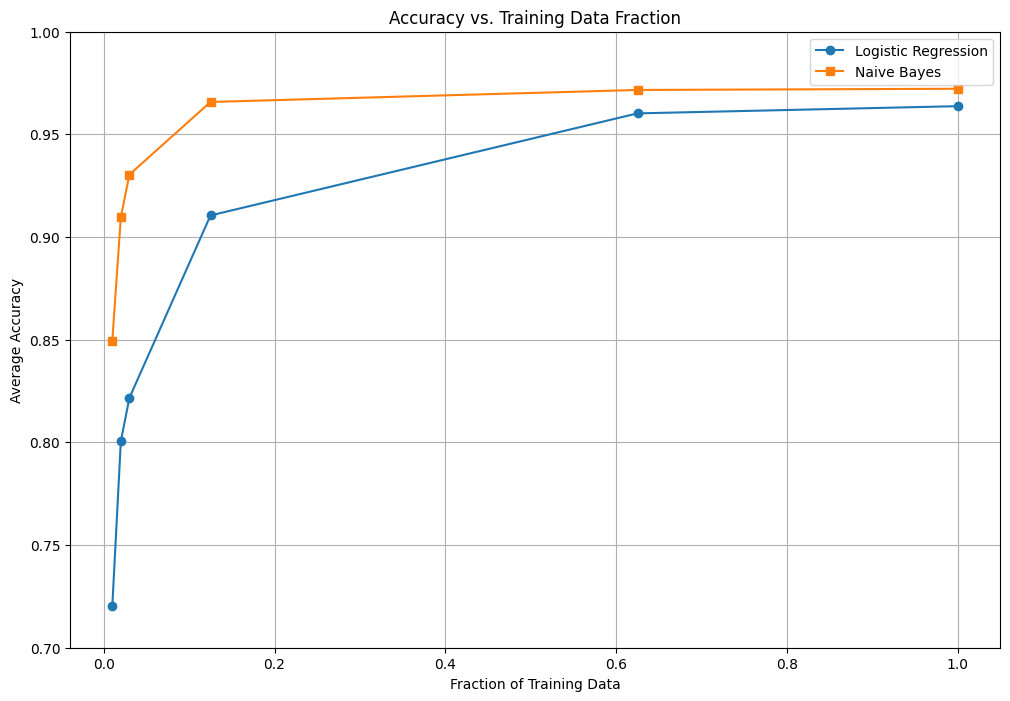

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(fracs, results[0], marker='o', label='Logistic Regression')
plt.plot(fracs, results[1], marker='s', label='Naive Bayes')

plt.xlabel('Fraction of Training Data')
plt.ylabel('Average Accuracy')
plt.ylim(0.7, 1)
plt.title('Accuracy vs. Training Data Fraction')
plt.legend()
plt.grid(True)
plt.show()
    